# <a id='toc1_'></a>[Imports](#toc0_)

In [1]:
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd

import seaborn as sns

import skimage.feature

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping #type: ignore
from tensorflow.keras.models import load_model #type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type: ignore

# <a id='toc2_'></a>[Load Data set](#toc0_)

In [2]:
land_cover_data = np.load('./Datasets/DS_Xdata.npy')
land_cover_labels = np.load('./Datasets/Ydata.npy')

# <a id='toc3_'></a>[Understanding Data](#toc0_)

In [3]:
print(f"Shape: {land_cover_data.shape}")
print(f"Sample count: {len(land_cover_labels)}")
print(f"Unique label: {np.unique(land_cover_labels)}")

Shape: (2100, 61, 61, 3)
Sample count: 2100
Unique label: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


# <a id='toc4_'></a>[Global constants](#toc0_)

In [4]:
#Value to replicate the random value generation(s) and results in the file
seeding_constant = 20

#Categories to be selected for classification for model 1 and model 2
category_count = 5

label_classes = ['agricultural', 'airplane', 'baseball diamond', 'beach', 'buildings', 'chaparral', 'dense residential', 'forest', 
'freeway', 'golf course', 'harbour', 'intersection', 'medium residential', 'mobile home park', 'overpass', 'parking lot', 
'river', 'runway', 'sparse residential', 'storage tanks', 'tennis court']

# Helper methods

## Confusion matrix

In [5]:
def confusion_matrix_helper(trueLabels, predictedlabels, title, figure_size=(8,6), color_map="Blues"):
    plt.ion()
    matrix_array = confusion_matrix(trueLabels, predictedlabels)

    cm_normalized = matrix_array.astype('float') / matrix_array.sum(axis=1, keepdims=True) * 100

    # Create a DataFrame for better visualization
    labels = []
    for i in np.unique(trueLabels):
        labels.append(label_classes[i])

    cm_df = pd.DataFrame(cm_normalized, index=labels, columns=labels)

    # Plot the heatmap
    plt.figure(figsize=figure_size)
    sns.heatmap(cm_df, annot=True, fmt=".2f", cmap=color_map, cbar_kws={'label': 'Percentage (%)'})

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    
    plt.show()

## 2D Scatterplot for cluster visualization

In [6]:
def scatter_plot2D(dataset, 
                   true_labels, 
                   predicted_labels,
                   xaxis_title, 
                   yaxis_title
                   ):
    plt.ion()

    # Create a figure with multiple subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    # Plot ground truth
    axs[0].scatter(dataset[:,0], 
                   dataset[:,1],
                   c=true_labels,
                   cmap='Accent'
                   )
    
    axs[0].set_xlabel(xaxis_title)
    axs[0].set_ylabel(yaxis_title)
    axs[0].set_title("Ground Truth")

    #Plot predicted truth
    axs[1].scatter(dataset[:,0], 
                   dataset[:,1],
                   c=predicted_labels,
                   cmap='Accent'
                   )
    
    axs[1].set_xlabel(xaxis_title)
    axs[1].set_ylabel(yaxis_title)
    axs[1].set_title("Predicted Categories")

    # Layout so plots do not overlap
    fig.tight_layout()

    plt.show()

## Image agumentation

In [7]:
def image_generator(image, num_augmented_images = 5):
    # Set up the ImageDataGenerator with your desired augmentations
    datagen = ImageDataGenerator(
        rotation_range=0,             # No random rotations
        shear_range=0.2,              # Shear transformations
        zoom_range=0.2,               # Zoom range (20%)
        horizontal_flip=True,         # Horizontal flip
        vertical_flip=True,           # Vertical flip
        fill_mode='nearest'  # Use custom rotation function
    )

    img_array = np.expand_dims(image, axis=0)  # Add a batch dimension

    # Array to hold augmented images
    augmented_images = []

    # Number of augmented images to generate
    num_augmented_images = 5

    # Generate augmented images and store them in the array
    for batch in datagen.flow(img_array, batch_size=1):
        augmented_images.append(batch[0])  # Add the augmented image to the list
        if len(augmented_images) >= num_augmented_images:
            break  # Stop after generating the desired number of augmented images


    # Convert the list of augmented images to a NumPy array for easier processing
    augmented_images_array = np.array(augmented_images)

    augmented_image_array_270=np.rot90(augmented_images_array, axes=(1,2))
    augmented_image_array_180=np.rot90(augmented_images_array, k=2)
    augmented_image_array_90=np.rot90(augmented_images_array, k=3, axes=(1,2))

    # merge all the images to a single array
    all_images_array = np.concatenate((augmented_images_array, augmented_image_array_90, augmented_image_array_180, augmented_image_array_270))

    return all_images_array


In [8]:
augmented_images = np.array(np.copy(land_cover_data))
augmented_label_list = np.copy(land_cover_labels).flatten()

for i in range(len(land_cover_data)):
    # Extract the image and its corresponding label
    images_result= image_generator(land_cover_data[i, :, :, :])
    # Append the augmented images to the list
    augmented_images = np.concatenate((augmented_images, images_result))

    repeated_labels = np.repeat(land_cover_labels[i], images_result.shape[0])  # Repeat the label for the batch of images
    
    # Append the repeated labels
    augmented_label_list = np.concatenate((augmented_label_list, repeated_labels))

# <a id='toc5_'></a>[Model 1 - Classification](#toc0_)

## <a id='toc5_1_'></a>[Selecting 5 categories and labels](#toc0_)

In [72]:
np.random.seed(seeding_constant)

unique_label_set = set(np.unique(land_cover_labels))

selected_categories = [np.random.randint(min(unique_label_set), 
                                         max(unique_label_set)) 
                        for _ in range(category_count)
                        ]

selected_land_cover_data = [] 
selected_land_cover_labels = [] 

for index, value in enumerate(land_cover_labels):
    if value[0] in selected_categories:
        selected_land_cover_data.append(land_cover_data[index])
        selected_land_cover_labels.append(value[0])

## <a id='toc5_2_'></a>[Split data to train(fit) and test(predict)](#toc0_)

In [73]:
split_list = train_test_split(selected_land_cover_data,
                              selected_land_cover_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

#Train data and labels for model 1 and 2
train_land_cover_data = split_list[0]
train_land_cover_labels = split_list[2]

#Test data and labels for model 1 and 2
test_land_cover_data = split_list[1]
test_land_cover_labels = split_list[3]

### <a id='toc5_2_1_'></a>[Understanding split data](#toc0_)

In [12]:
unique_train_labels = set(np.unique(train_land_cover_labels))

print("Train Data diversification")
for i in unique_train_labels:
    print(f"Label {i} : {train_land_cover_labels.count(i)}")

Train Data diversification
Label 3 : 87
Label 7 : 91
Label 9 : 93
Label 11 : 87
Label 15 : 92


In [13]:
unique_test_labels = np.unique(test_land_cover_labels)
print("Test Data diversification")
for i in unique_test_labels:
    print(f"Label {i} : {test_land_cover_labels.count(i)}")

Test Data diversification
Label 3 : 13
Label 7 : 9
Label 9 : 7
Label 11 : 13
Label 15 : 8


### Data reshape


In [74]:
# Reshape each image to a 1D array
num_features = np.prod(train_land_cover_data[0].shape) 

train_land_cover_data_reshaped = np.array([x.reshape(num_features) for x in train_land_cover_data])
test_land_cover_data_reshaped = np.array([x.reshape(num_features) for x in test_land_cover_data])

## <a id='toc5_4_'></a>[Logistic regression](#toc0_)

### <a id='toc5_4_1_'></a>[Without hyperparamter tuning](#toc0_)

In [15]:
# Train a classifier on the reduced training data
logistic_classifier1 = LogisticRegression(max_iter=1000)
logistic_classifier1.fit(train_land_cover_data_reshaped, train_land_cover_labels)

# Predict labels for the reduced test data
predicted_labels_lr1 = logistic_classifier1.predict(test_land_cover_data_reshaped)

print("Accuracy:",logistic_classifier1.score(test_land_cover_data_reshaped, test_land_cover_labels))

Accuracy: 0.6


#### <a id='toc5_4_1_1_'></a>[Confusion matrix and other visualizations](#toc0_)

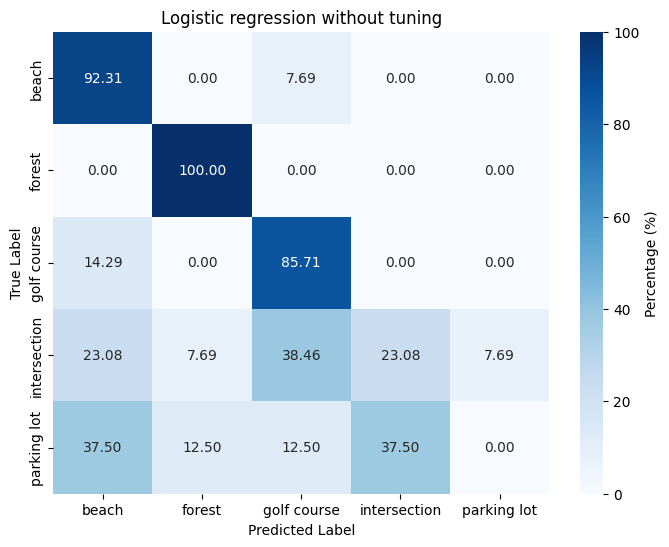

In [32]:
confusion_matrix_helper(test_land_cover_labels, predicted_labels_lr1, 'Logistic regression without tuning')

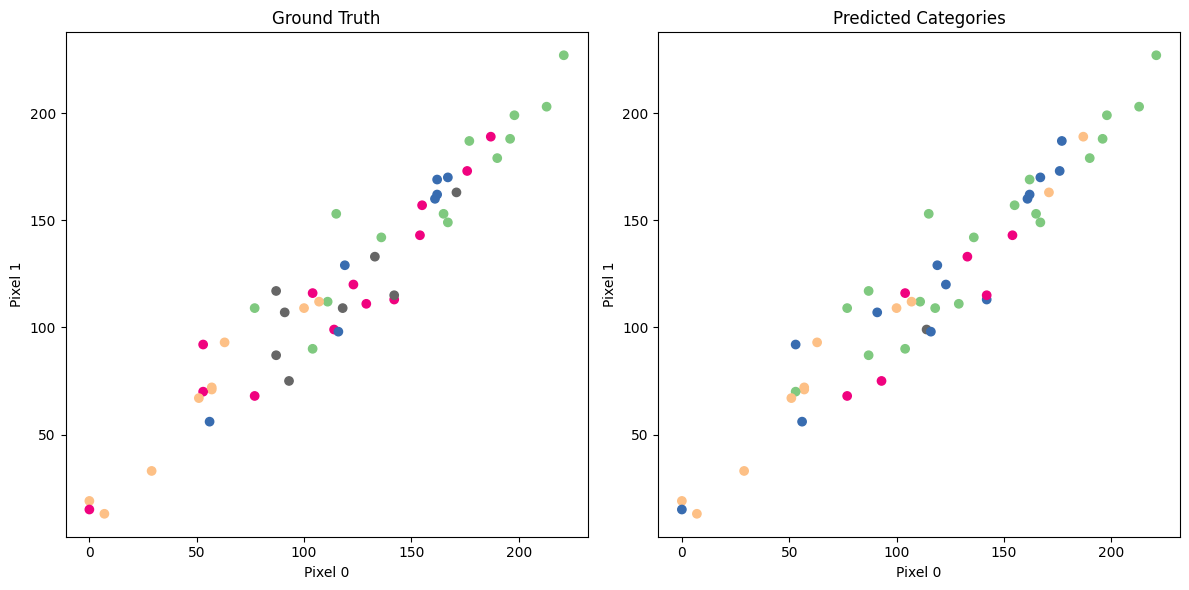

In [23]:
scatter_plot2D(test_land_cover_data_reshaped, 
               test_land_cover_labels, 
               predicted_labels_lr1,
               'Pixel 0',
               'Pixel 1'
               )

### <a id='toc5_4_2_'></a>[With hyperparameter Tuning](#toc0_)

In [22]:
# Train a classifier on the reduced training data
#sag 15
logistic_classifier2 = LogisticRegression(max_iter=2500, solver='sag', C=15)
logistic_classifier2.fit(train_land_cover_data_reshaped, train_land_cover_labels)

# Predict labels for the reduced test data
predicted_labels_lr2 = logistic_classifier2.predict(test_land_cover_data_reshaped)

print("Accuracy", logistic_classifier2.score(test_land_cover_data_reshaped, test_land_cover_labels))

0.54


#### <a id='toc5_4_2_1_'></a>[Confusion matrix and other visualizations](#toc0_)

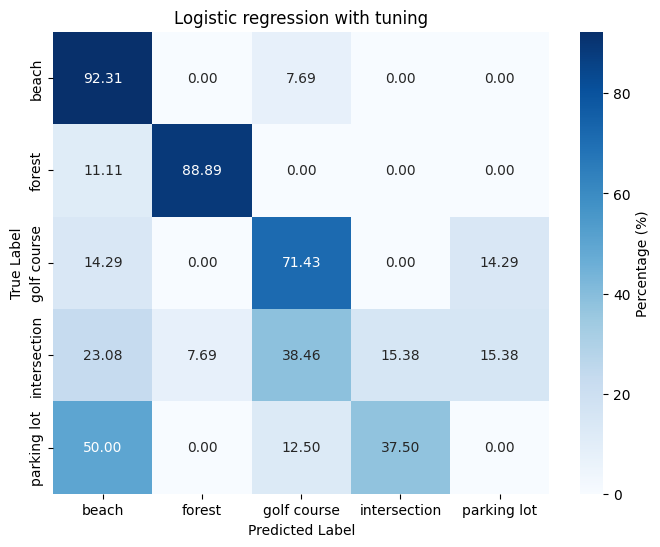

In [33]:
confusion_matrix_helper(test_land_cover_labels, predicted_labels_lr2, 'Logistic regression with tuning')

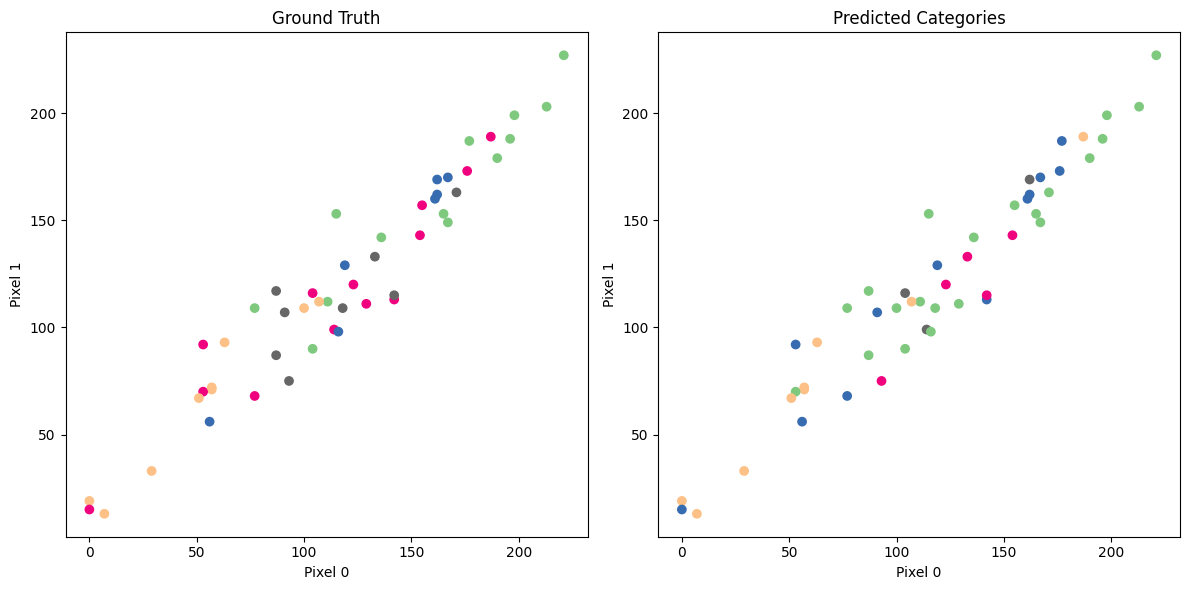

In [34]:
scatter_plot2D(test_land_cover_data_reshaped, 
               test_land_cover_labels, 
               predicted_labels_lr2,
               'Pixel 0',
               'Pixel 1'
               )

### <a id='toc5_4_3_'></a>[With Normalization](#toc0_)

In [35]:
normalized_train_data = train_land_cover_data_reshaped/255
normalized_test_data = test_land_cover_data_reshaped/255

# Train a classifier on the reduced training data
logistic_classifier3 = LogisticRegression(max_iter=1000)
logistic_classifier3.fit(normalized_train_data, train_land_cover_labels)

# Predict labels for the reduced test data
predicted_labels_lr3 = logistic_classifier3.predict(normalized_test_data)

print(logistic_classifier3.score(normalized_test_data, test_land_cover_labels))

0.62


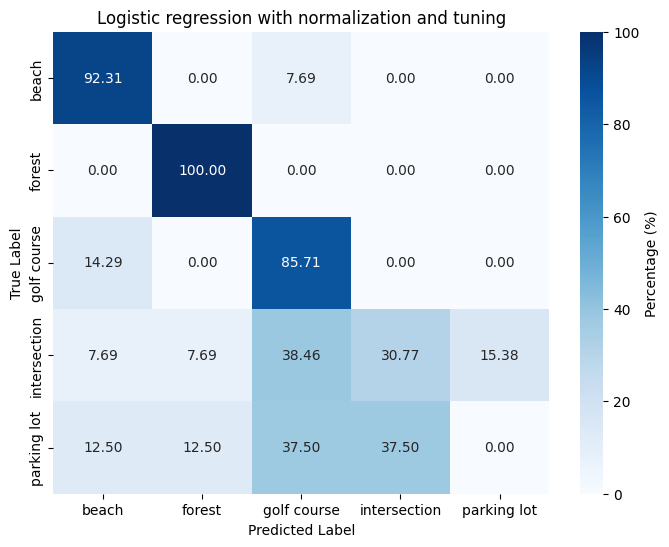

In [36]:
confusion_matrix_helper(test_land_cover_labels, predicted_labels_lr3, 'Logistic regression with normalization and tuning')

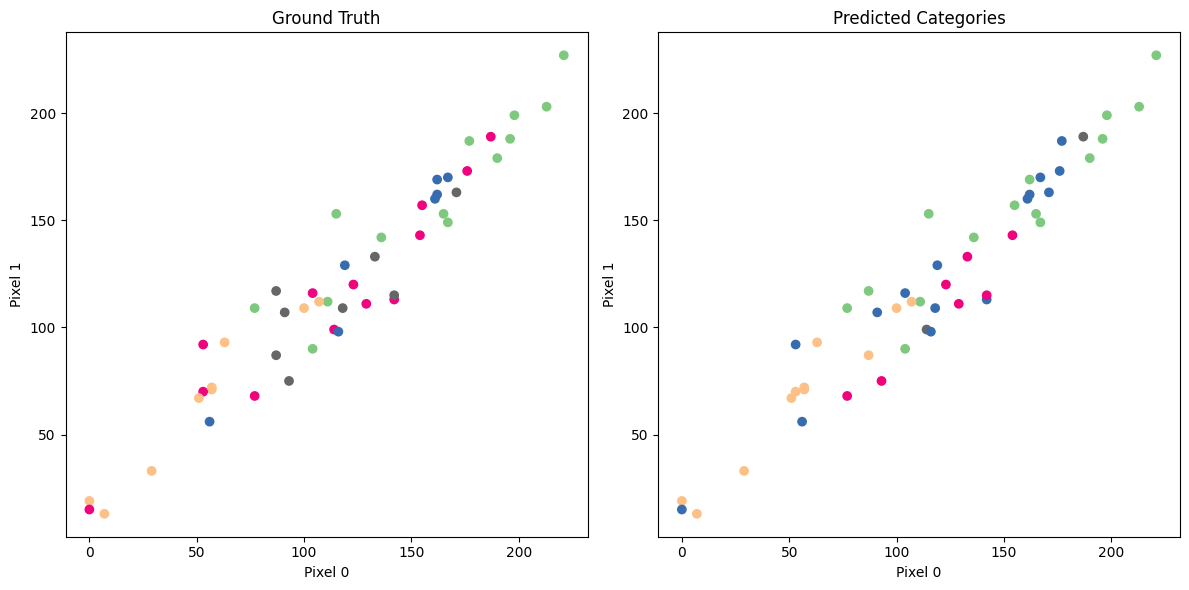

In [37]:
scatter_plot2D(test_land_cover_data_reshaped, 
               test_land_cover_labels, 
               predicted_labels_lr3,
               'Pixel 0',
               'Pixel 1'
               )

## SVM

### Without Normalization

In [53]:
svm1 = SVC(kernel='rbf', C=2)
svm1.fit(train_land_cover_data_reshaped, train_land_cover_labels)
predicted_labels_svm1 = svm1.predict(test_land_cover_data_reshaped)
print(f"Accuracy:", svm1.score(test_land_cover_data_reshaped, test_land_cover_labels))

Accuracy: 0.86


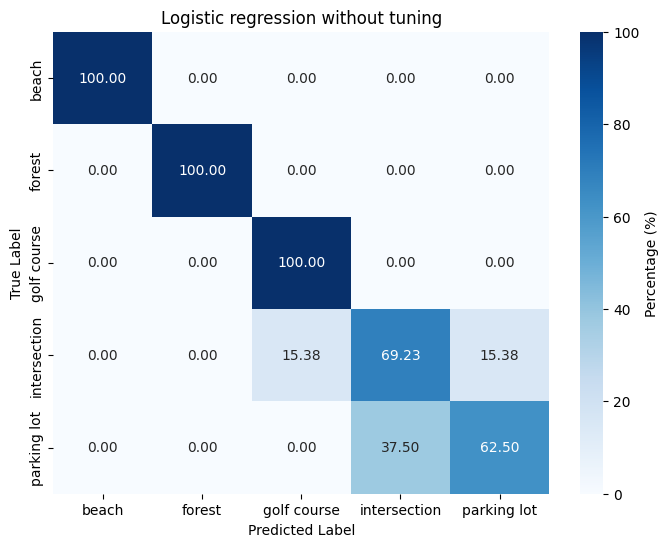

In [52]:
confusion_matrix_helper(test_land_cover_labels, predicted_labels_svm1, 'Logistic regression without tuning')

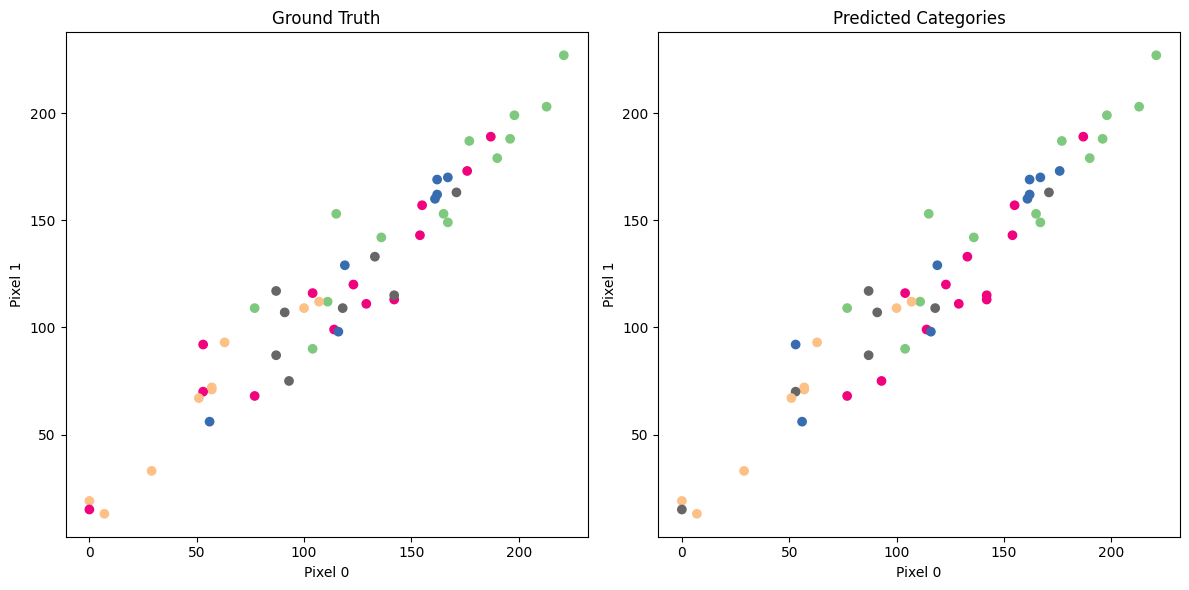

In [64]:
scatter_plot2D(test_land_cover_data_reshaped, 
               test_land_cover_labels, 
               predicted_labels_svm1,
               'Pixel 0',
               'Pixel 1'
               )

### With Normalization and hyper parameter tuning

In [60]:
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_train_data = scaler.fit_transform(train_land_cover_data_reshaped)
scaled_test_data = scaler.transform(test_land_cover_data_reshaped)

In [ ]:
svm2 = SVC(kernel='rbf', C=0.)
svm2.fit(scaled_train_data, train_land_cover_labels)
predicted_labels_svm2 = svm2.predict(scaled_test_data)
print(f"Accuracy:", svm2.score(scaled_test_data, test_land_cover_labels))

Accuracy: 0.76


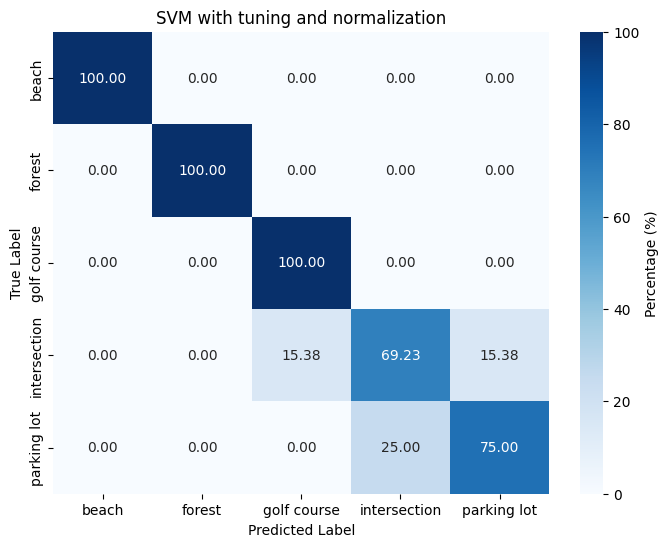

In [63]:
confusion_matrix_helper(test_land_cover_labels, predicted_labels_svm2, 'SVM with tuning and normalization')

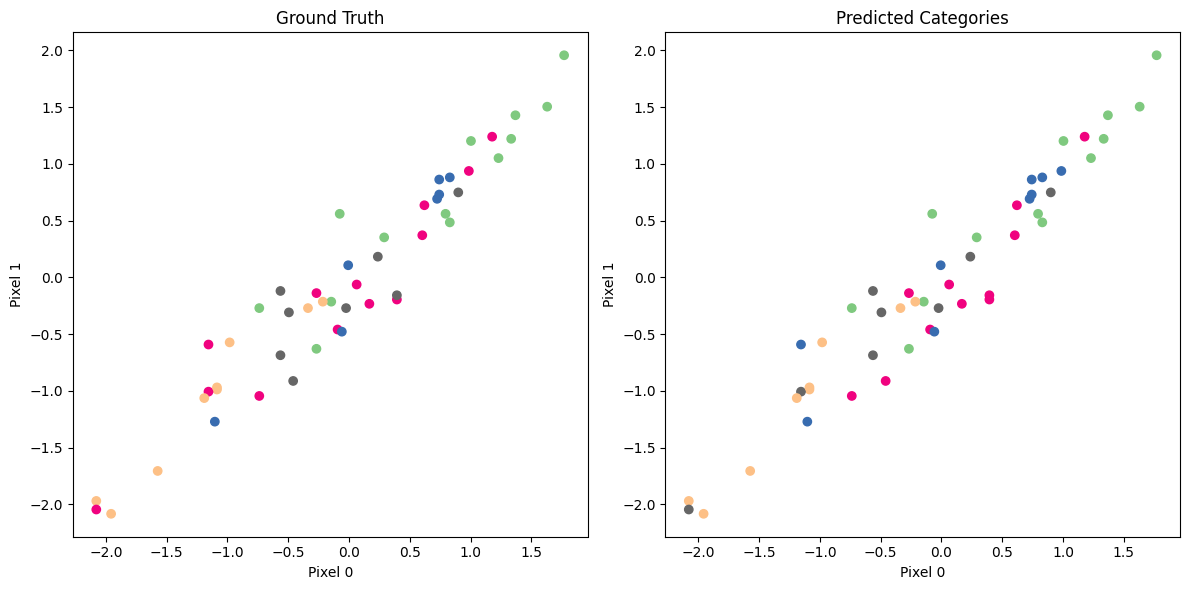

In [65]:
scatter_plot2D(scaled_test_data, 
               test_land_cover_labels, 
               predicted_labels_svm2,
               'Pixel 0',
               'Pixel 1'
               )

#### Grid search optimization for best c value

In [ ]:
# Train a classifier on the reduced training data
for i in range(1, 10):
    svm = SVC(kernel='rbf', C=i)
    svm.fit(scaled_train_data, train_land_cover_labels)
    score = svm.score(scaled_test_data, test_land_cover_labels)
    if(score>=0.88):
        print(f"{round(float(i), 3)}:{score}")

1.0:0.88
2.0:0.88
3.0:0.88
4.0:0.88
5.0:0.88
6.0:0.88
7.0:0.88
8.0:0.88
9.0:0.88


In [111]:
# Train a classifier on the reduced training data
for i in np.linspace(0.9, 1.132, 20):
    svm = SVC(kernel='rbf', C=i)
    svm.fit(scaled_train_data, train_land_cover_labels)
    score = svm.score(scaled_test_data, test_land_cover_labels)
    print(f"{round(float(i), 3)}:{score}")

0.9:0.86
0.912:0.86
0.924:0.86
0.937:0.86
0.949:0.88
0.961:0.88
0.973:0.88
0.985:0.88
0.998:0.88
1.01:0.88
1.022:0.88
1.034:0.88
1.047:0.88
1.059:0.88
1.071:0.88
1.083:0.88
1.095:0.88
1.108:0.86
1.12:0.86
1.132:0.86


# <a id='toc6_'></a>[Model 2 - Preprocessing with classification](#toc0_)

## <a id='toc6_1_'></a>[Pre-processing with LDA feature/dimensionality reduction](#toc0_)

### <a id='toc6_1_1_'></a>[LDA without noramlisation and no hyper parameters](#toc0_)

In [75]:
lda1= LDA(n_components=4)
train_land_cover_data_transformed1 = lda1.fit_transform(train_land_cover_data_reshaped, train_land_cover_labels)

test_land_cover_data_transformed1 = lda1.transform(test_land_cover_data_reshaped)

#### Logistic regression

In [80]:
# Train a classifier on the reduced training data
logistic_classifier4 = LogisticRegression(max_iter=1000)
logistic_classifier4.fit(train_land_cover_data_transformed1, train_land_cover_labels)

# Predict labels for the reduced test data
predicted_labels_lr4 = logistic_classifier4.predict(test_land_cover_data_transformed1)

print("Accuracy:", logistic_classifier4.score(test_land_cover_data_transformed1, test_land_cover_labels))

Accuracy: 0.62


#### SVM

In [121]:
svm3 = SVC()
svm3.fit(train_land_cover_data_transformed1, train_land_cover_labels)
predicted_labels_svm3 = svm3.predict(test_land_cover_data_transformed1)
print(f"Accuracy:", svm3.score(test_land_cover_data_transformed1, test_land_cover_labels))

Accuracy: 0.56


#### Confusion matrix and visualizations

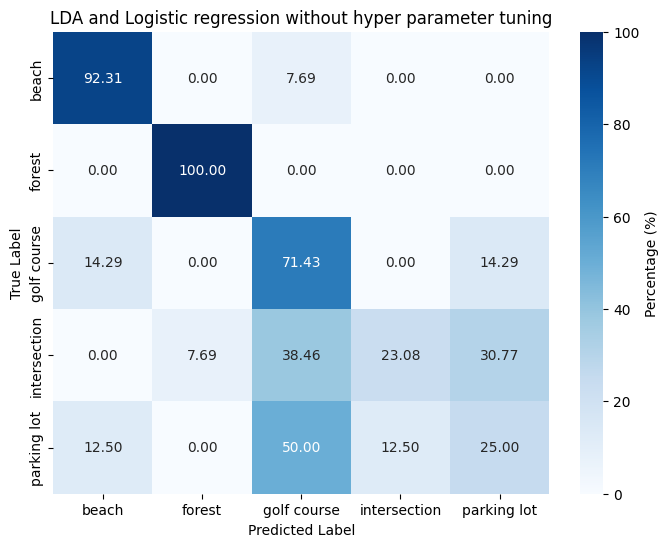

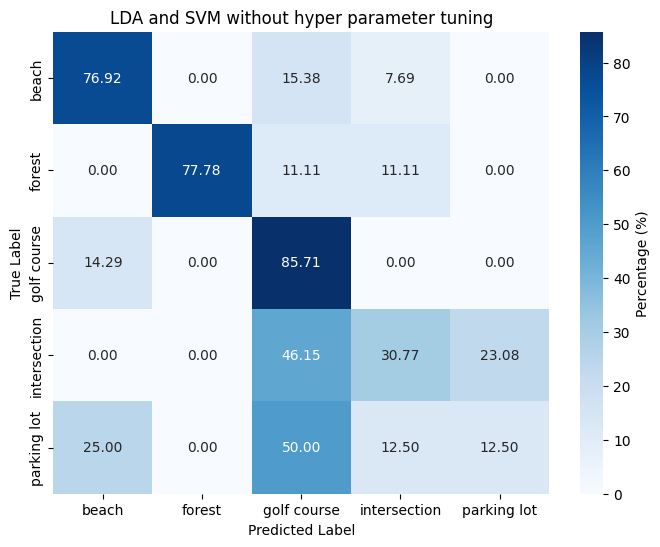

In [122]:
confusion_matrix_helper(test_land_cover_labels, predicted_labels_lr4, 'LDA and Logistic regression without hyper parameter tuning')
confusion_matrix_helper(test_land_cover_labels, predicted_labels_svm3, 'LDA and SVM without hyper parameter tuning')

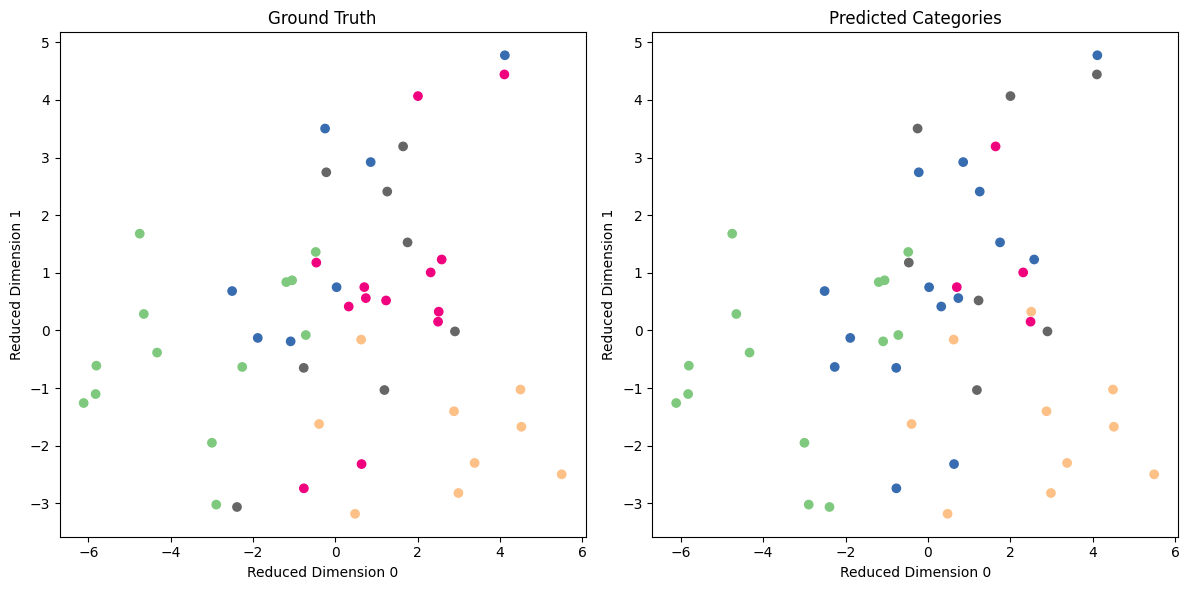

In [88]:
scatter_plot2D(test_land_cover_data_transformed1, 
               test_land_cover_labels, 
               predicted_labels_lr4,
               'Reduced Dimension 0',
               'Reduced Dimension 1'
               )

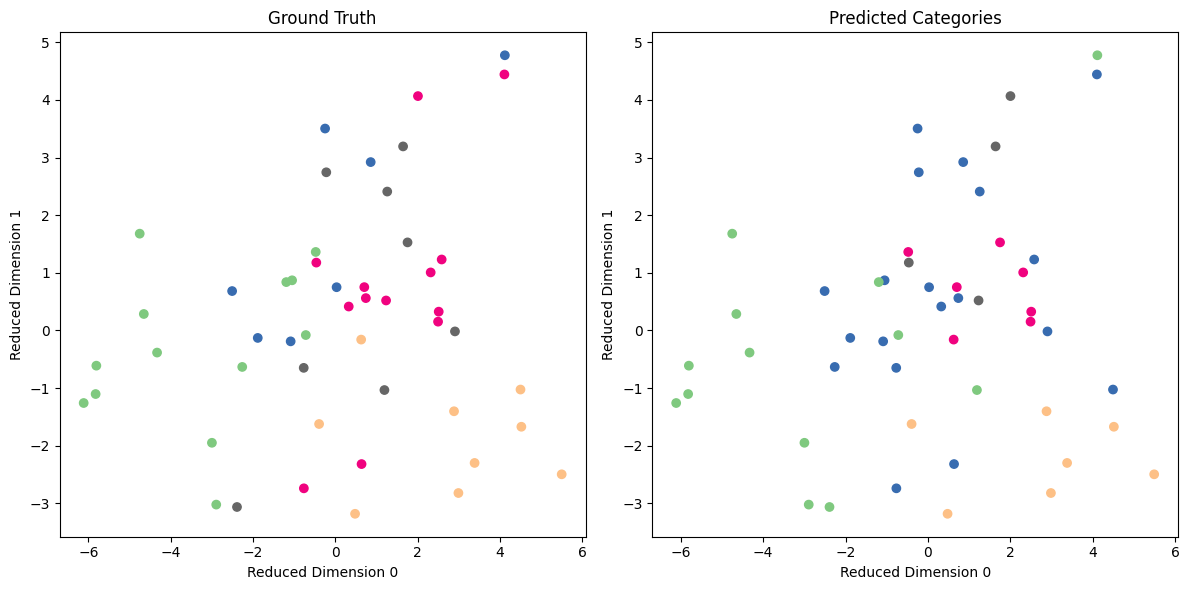

In [123]:
scatter_plot2D(test_land_cover_data_transformed1, 
               test_land_cover_labels, 
               predicted_labels_svm3,
               'Reduced Dimension 0',
               'Reduced Dimension 1'
               )


### <a id='toc6_1_2_'></a>[LDA with noramlisation and no hyper parameters](#toc0_)

In [98]:
normalized_train_data = train_land_cover_data_reshaped/255
normalized_test_data = test_land_cover_data_reshaped/255

In [90]:
lda2= LDA(n_components=4, )
train_land_cover_data_transformed2= lda2.fit_transform(normalized_train_data, train_land_cover_labels)

test_land_cover_data_transformed2 = lda2.transform(normalized_test_data)


#### Logistic Regression

In [92]:
# Train a classifier on the reduced training data
logistic_classifier5 = LogisticRegression(max_iter=1000)
logistic_classifier5.fit(train_land_cover_data_transformed2, train_land_cover_labels)

# Predict labels for the reduced test data
predicted_labels_lr5 = logistic_classifier5.predict(test_land_cover_data_transformed2)

print("Accuracy:",logistic_classifier5.score(test_land_cover_data_transformed2, test_land_cover_labels))

Accuracy: 0.62


#### SVM

In [124]:
svm4 = SVC()
svm4.fit(train_land_cover_data_transformed2, train_land_cover_labels)
predicted_labels_svm4 = svm4.predict(test_land_cover_data_transformed2)
print(f"Accuracy:", svm4.score(test_land_cover_data_transformed2, test_land_cover_labels))

Accuracy: 0.56


#### Confusion matrix and visualizations

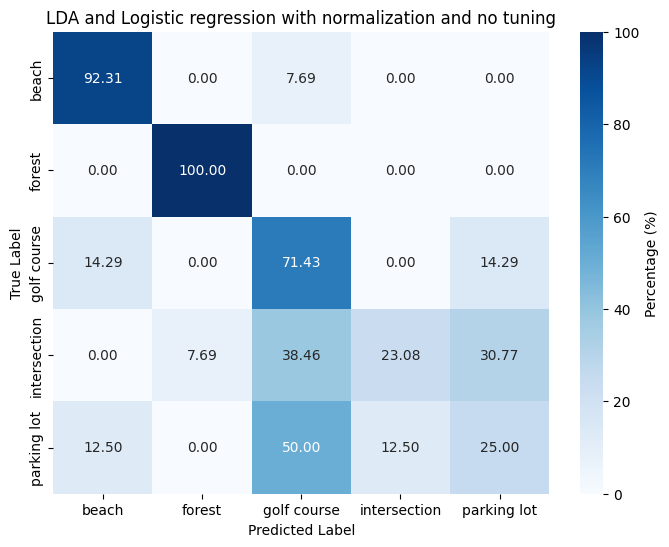

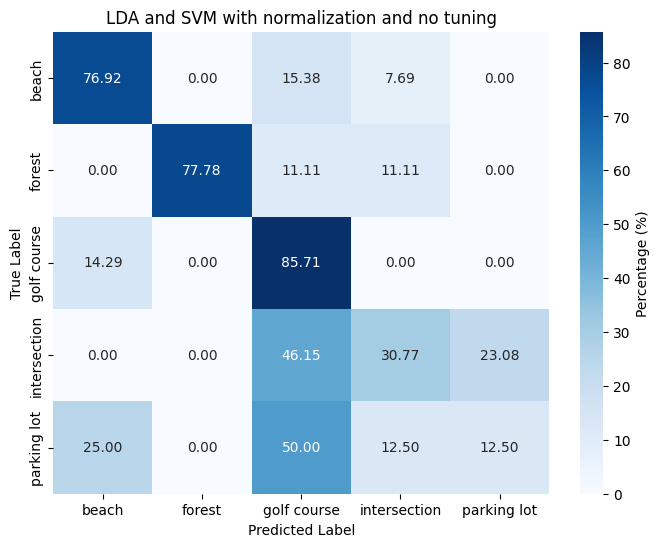

In [212]:
confusion_matrix_helper(test_land_cover_labels, predicted_labels_lr5, 'LDA and Logistic regression with normalization and no tuning')
confusion_matrix_helper(test_land_cover_labels, predicted_labels_svm4, 'LDA and SVM with normalization and no tuning')

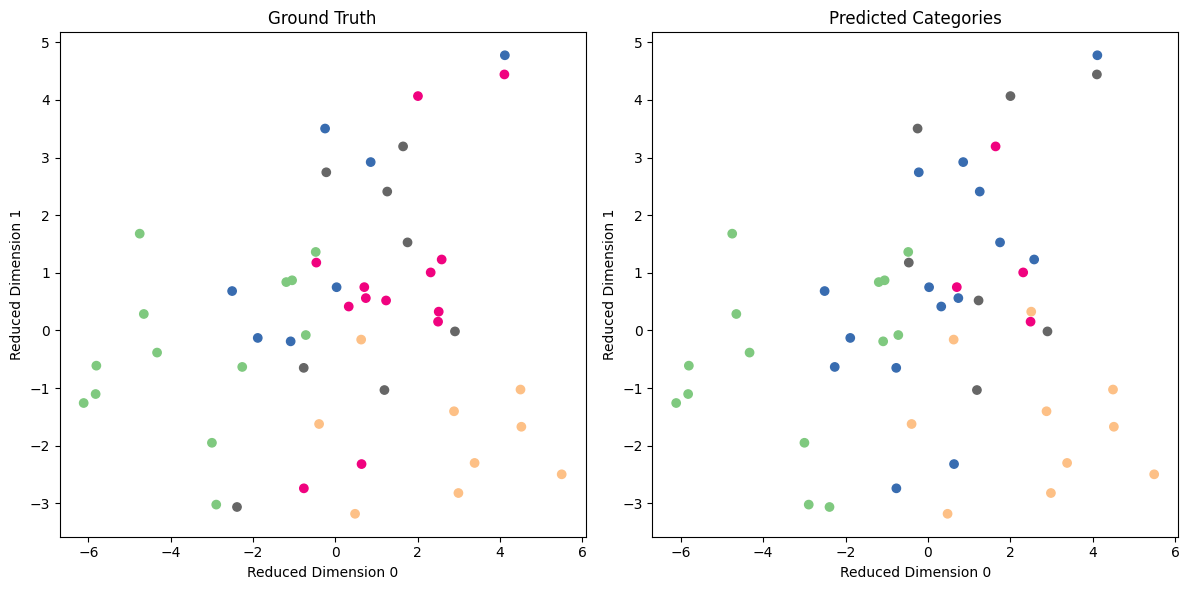

In [93]:
scatter_plot2D(test_land_cover_data_transformed2, 
               test_land_cover_labels, 
               predicted_labels_lr5,
               'Reduced Dimension 0',
               'Reduced Dimension 1'
               )

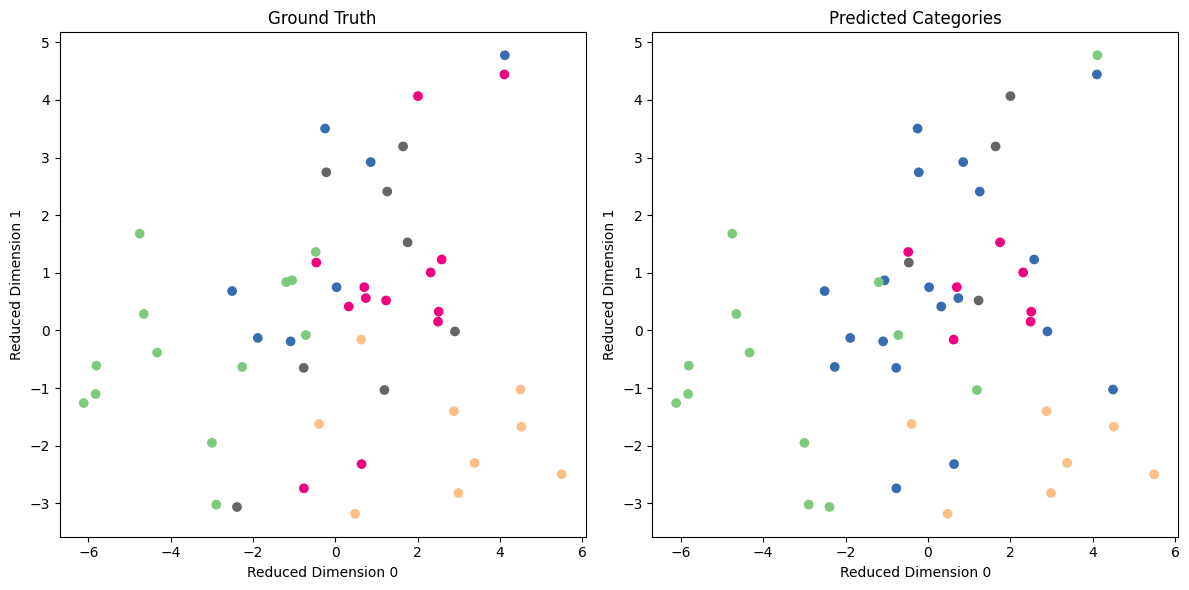

In [126]:
scatter_plot2D(test_land_cover_data_transformed2, 
               test_land_cover_labels, 
               predicted_labels_svm4,
               'Reduced Dimension 0',
               'Reduced Dimension 1'
               )

### <a id='toc6_1_3_'></a>[LDA with noramlisation and hyper parameters](#toc0_)

In [94]:
lda3= LDA(n_components=3, solver="eigen", shrinkage='auto')
train_land_cover_data_transformed3 = lda3.fit_transform(normalized_train_data, train_land_cover_labels)

test_land_cover_data_transformed3 = lda3.transform(normalized_test_data)


#### Logistic Regression

In [96]:
logistic_classifier6 = LogisticRegression(max_iter=1000, C=5.294)
logistic_classifier6.fit(train_land_cover_data_transformed3, train_land_cover_labels)

# Predict labels for the reduced test data
predicted_labels_lr6 = logistic_classifier6.predict(test_land_cover_data_transformed3)
print(f"{logistic_classifier6.score(test_land_cover_data_transformed3, test_land_cover_labels)}")

0.6


#### SVM

In [154]:
svm5 = SVC(kernel='poly', degree=4, C=5)
svm5.fit(train_land_cover_data_transformed3, train_land_cover_labels)
predicted_labels_svm5 = svm5.predict(test_land_cover_data_transformed3)
print(f"Accuracy:", svm5.score(test_land_cover_data_transformed3, test_land_cover_labels))

Accuracy: 0.52


#### Confusion matrix and visualisations

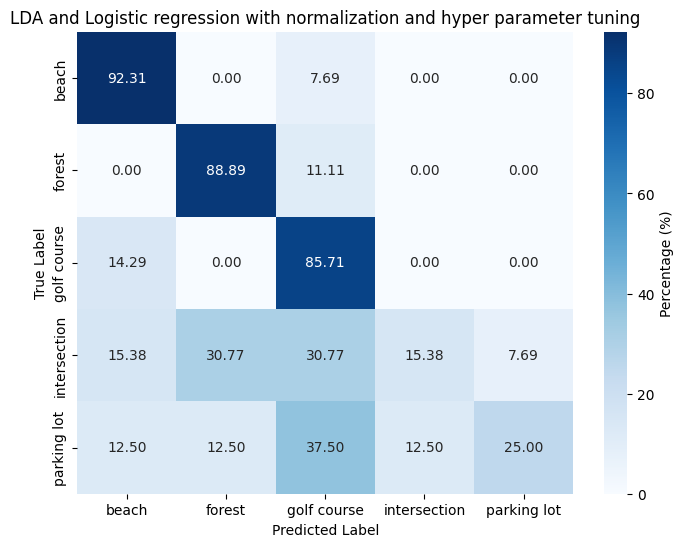

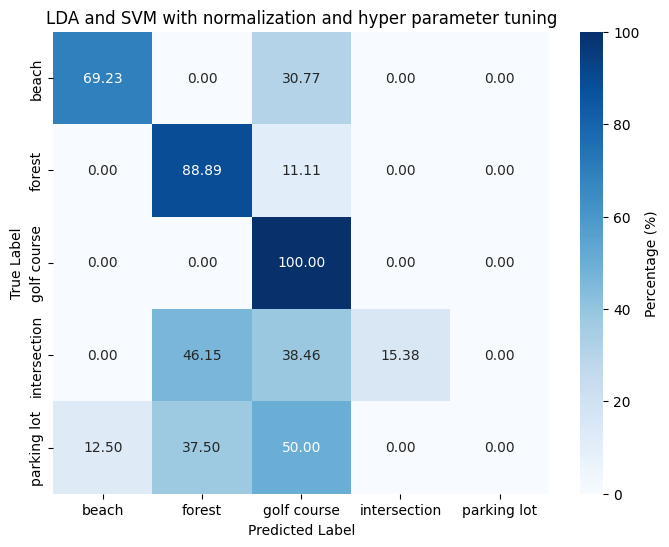

In [155]:
confusion_matrix_helper(test_land_cover_labels, predicted_labels_lr6, 'LDA and Logistic regression with normalization and hyper parameter tuning')
confusion_matrix_helper(test_land_cover_labels, predicted_labels_svm5, 'LDA and SVM with normalization and hyper parameter tuning')

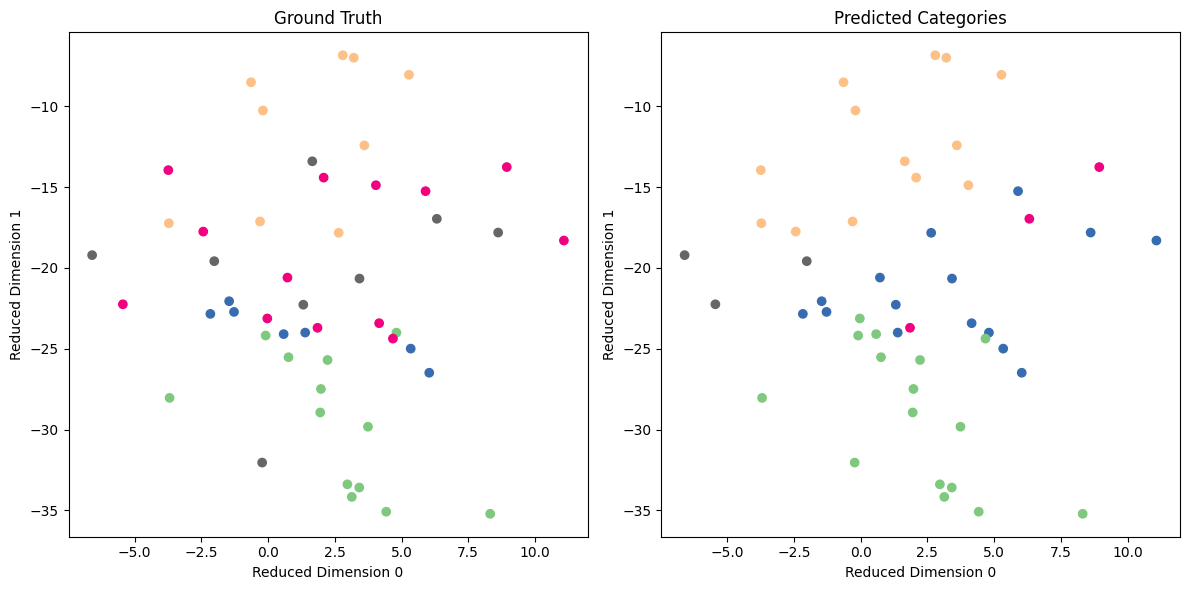

In [98]:
scatter_plot2D(test_land_cover_data_transformed3, 
               test_land_cover_labels, 
               predicted_labels_lr6,
               'Reduced Dimension 0',
               'Reduced Dimension 1'
               )

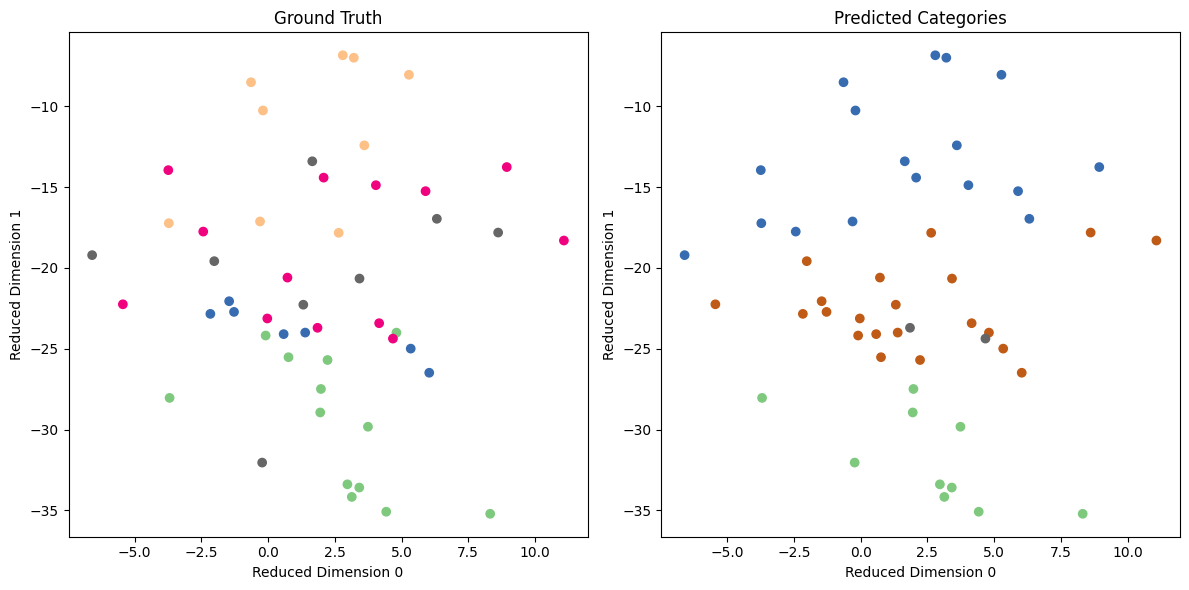

In [156]:
scatter_plot2D(test_land_cover_data_transformed3, 
               test_land_cover_labels, 
               predicted_labels_svm5,
               'Reduced Dimension 0',
               'Reduced Dimension 1'
               )

#### <a id='toc6_1_3_1_'></a>[Grid search optimization to find best c value](#toc0_)

In [99]:
# Train a classifier on the reduced training data
for i in np.linspace(5, 7, 10000):
    classifier = LogisticRegression(max_iter=1000, C=round(float(i), 3))
    classifier.fit(train_land_cover_data_transformed3, train_land_cover_labels)

    # Predict labels for the reduced test data
    predicted_labels6 = classifier.predict(test_land_cover_data_transformed3)
    score = classifier.score(test_land_cover_data_transformed3, test_land_cover_labels)
    if(score>0.58):
        print(f"{round(float(i), 3)}:{score}")

5.294:0.6
5.294:0.6
5.294:0.6
5.294:0.6
5.294:0.6
6.091:0.6
6.091:0.6
6.091:0.6
6.091:0.6
6.091:0.6


## <a id='toc6_2_'></a>[Pre-processing with HOG feature extraction reduction](#toc0_)

In [234]:
hog_features = []

for index, image in enumerate(np.array(selected_land_cover_data)):
    hog_feature, hog_image = skimage.feature.hog(image, 
                                                 pixels_per_cell=[10, 10], 
                                                 cells_per_block=[5, 5], 
                                                 visualize=True,
                                                 channel_axis=2
                                                )

    hog_features.append(hog_feature)

In [159]:
np.array(hog_features).shape

(500, 900)

In [160]:
split_list_post_hog = train_test_split(hog_features,
                                       selected_land_cover_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_data_post_hog = np.array(split_list_post_hog[0])
test_data_post_hog = np.array(split_list_post_hog[1])

train_labels_post_hog = np.array(split_list_post_hog[2])
test_labels_post_hog = np.array(split_list_post_hog[3])


### Logistic Regression

In [187]:
logistic_classifier7 = LogisticRegression(max_iter=1000)
logistic_classifier7.fit(train_data_post_hog, train_labels_post_hog)

# Predict labels for the reduced test data
predicted_labels_lr7 = logistic_classifier7.predict(test_data_post_hog)
print(f"Accuracy: {logistic_classifier7.score(test_data_post_hog, test_labels_post_hog)}")

Accuracy: 0.9


### SVM

In [184]:
svm6 = SVC(kernel='rbf')
svm6.fit(train_data_post_hog, train_labels_post_hog)
predicted_labels_svm6 = svm6.predict(test_data_post_hog)
print(f"Accuracy:", svm6.score(test_data_post_hog, test_labels_post_hog))

Accuracy: 0.9


### Confusion matrix and visualisations

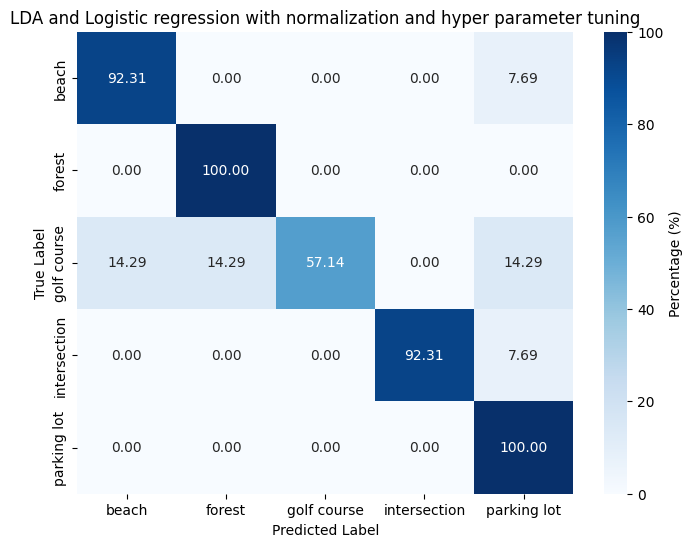

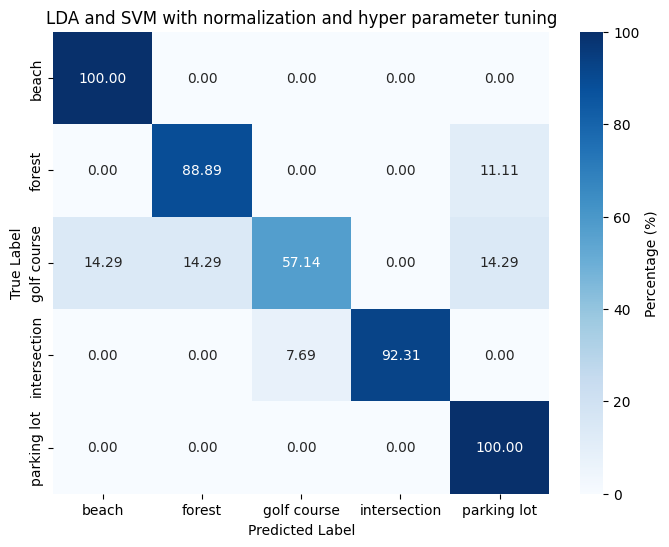

In [188]:
confusion_matrix_helper(test_labels_post_hog, predicted_labels_lr7, 'LDA and Logistic regression with normalization and hyper parameter tuning')
confusion_matrix_helper(test_labels_post_hog, predicted_labels_svm6, 'LDA and SVM with normalization and hyper parameter tuning')

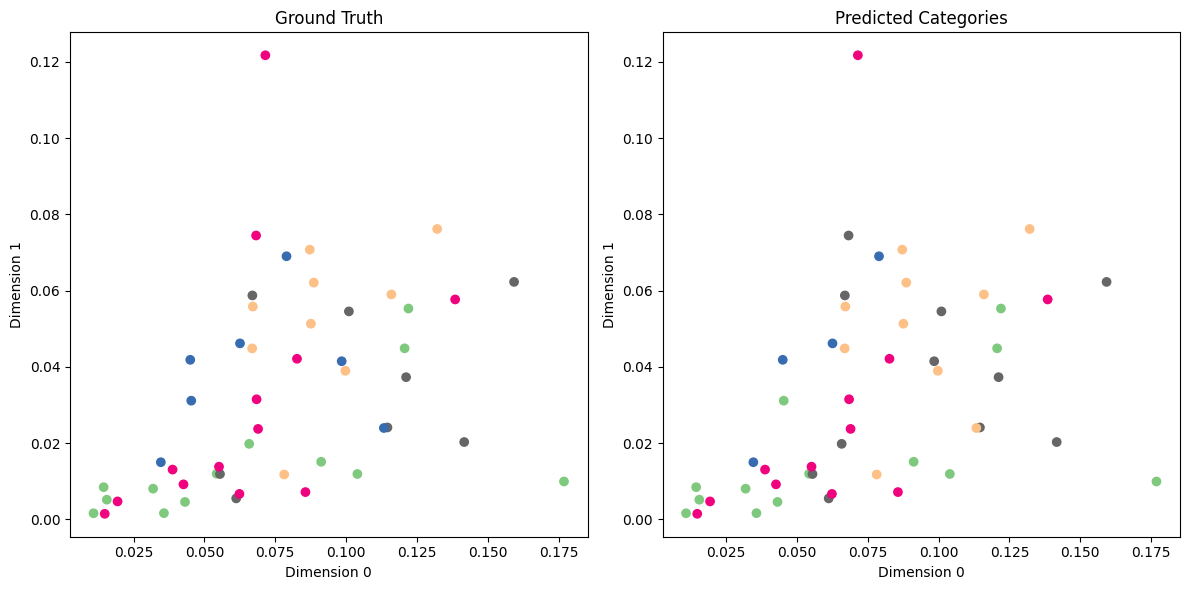

In [191]:
scatter_plot2D(test_data_post_hog, 
               test_labels_post_hog, 
               predicted_labels_lr7,
               'Dimension 0',
               'Dimension 1'
               )

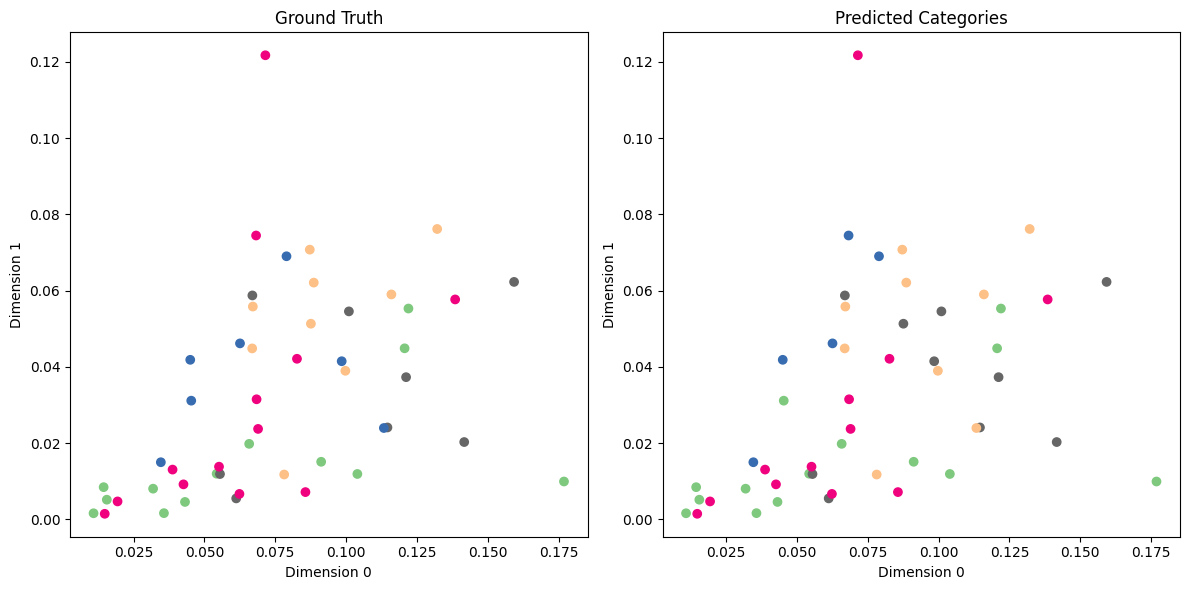

In [192]:
scatter_plot2D(test_data_post_hog, 
               test_labels_post_hog, 
               predicted_labels_svm6,
               'Dimension 0',
               'Dimension 1'
               )

### Optimization to find best params

In [185]:
for c in np.linspace(1,11,100): 
    svm = SVC(kernel='rbf', C=c)
    svm.fit(train_data_post_hog, train_labels_post_hog)
    score = svm.score(test_data_post_hog, test_labels_post_hog)
    if score>0.9:
        print(f"Accuracy:{score}, C=:{c}" )

In [ ]:
for deg in range(7,20):
    for c in range(1,11): 
        svm = SVC(kernel='poly', degree=deg, C=c)
        svm.fit(train_data_post_hog, train_labels_post_hog)
        score = svm.score(test_data_post_hog, test_labels_post_hog)
        if score>=0.9:
            print(f"Accuracy:{score}, degree:{deg}, C=:{c}" )

Accuracy:0.9, degree:7, C=:1
Accuracy:0.9, degree:7, C=:2
Accuracy:0.9, degree:7, C=:3
Accuracy:0.9, degree:7, C=:4
Accuracy:0.9, degree:7, C=:5
Accuracy:0.9, degree:7, C=:6
Accuracy:0.9, degree:7, C=:7
Accuracy:0.9, degree:7, C=:8
Accuracy:0.9, degree:7, C=:9
Accuracy:0.9, degree:7, C=:10
Accuracy:0.9, degree:8, C=:1
Accuracy:0.9, degree:8, C=:2
Accuracy:0.9, degree:8, C=:3
Accuracy:0.9, degree:8, C=:4
Accuracy:0.9, degree:8, C=:5
Accuracy:0.9, degree:8, C=:6
Accuracy:0.9, degree:8, C=:7
Accuracy:0.9, degree:8, C=:8
Accuracy:0.9, degree:8, C=:9
Accuracy:0.9, degree:8, C=:10


# <a id='toc7_'></a>[Model 3 - CNN](#toc0_)

## <a id='toc7_1_'></a>[Model 3A - CNN without data agumentation](#toc0_)

### <a id='toc7_1_1_'></a>[Split Data and its overview](#toc0_)

In [29]:
split_list_cnn = train_test_split(land_cover_data,
                              land_cover_labels,
                              test_size = 0.2,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_cnn_data = split_list_cnn[0]
train_cnn_labels = split_list_cnn[2]

#Test data - 10% of train data
test_cnn_data = split_list_cnn[1]
test_cnn_labels= split_list_cnn[3]

In [30]:
unique_train_cnn_labels = set(np.unique(train_cnn_labels))

print("Train Data diversification")
for i in unique_train_cnn_labels:
    print(f"Label {i} : {list(train_cnn_labels).count(i)}")

Train Data diversification
Label 0 : 83
Label 1 : 82
Label 2 : 76
Label 3 : 79
Label 4 : 74
Label 5 : 78
Label 6 : 79
Label 7 : 75
Label 8 : 74
Label 9 : 81
Label 10 : 86
Label 11 : 85
Label 12 : 90
Label 13 : 78
Label 14 : 83
Label 15 : 81
Label 16 : 84
Label 17 : 79
Label 18 : 79
Label 19 : 80
Label 20 : 74


In [31]:
unique_test_cnn_labels = np.unique(test_cnn_labels)
print("Test Data diversification")
for i in unique_test_cnn_labels:
    print(f"Label {i} : {list(test_cnn_labels).count(i)}")

Test Data diversification
Label 0 : 17
Label 1 : 18
Label 2 : 24
Label 3 : 21
Label 4 : 26
Label 5 : 22
Label 6 : 21
Label 7 : 25
Label 8 : 26
Label 9 : 19
Label 10 : 14
Label 11 : 15
Label 12 : 10
Label 13 : 22
Label 14 : 17
Label 15 : 19
Label 16 : 16
Label 17 : 21
Label 18 : 21
Label 19 : 20
Label 20 : 26


### <a id='toc7_1_2_'></a>[CNN](#toc0_)

In [32]:
normalized_cnn_train_data = train_cnn_data/255
normalized_cnn_test_data = test_cnn_data/255

In [33]:
#Filter variables for cnn
filter_count = 32
multiplier=0

#Define the model with layers and hyperparams as per requiremnets
model_cnn = tf.keras.Sequential(layers=[
    tf.keras.layers.Conv2D(filter_count, kernel_size=(3,3), activation=tf.nn.leaky_relu),    
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu, use_bias=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+2)), kernel_size=(3,3), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(filter_count*(2**(multiplier+4)), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(len(np.unique(land_cover_labels)), activation = tf.nn.softmax)])

#Add the optimizer, loss, metrics and finalize the configuration
model_cnn.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_cnn = model_cnn.fit(normalized_cnn_train_data,
                            train_cnn_labels,
                            epochs = 20,
                            validation_split = 0.1,
                            verbose = 1
                            )

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 4.5084 - sparse_categorical_accuracy: 0.0937 - val_loss: 3.0317 - val_sparse_categorical_accuracy: 0.0655
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 2.3803 - sparse_categorical_accuracy: 0.3439 - val_loss: 3.3450 - val_sparse_categorical_accuracy: 0.0714
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 1.8702 - sparse_categorical_accuracy: 0.4442 - val_loss: 3.5227 - val_sparse_categorical_accuracy: 0.0298
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 1.6290 - sparse_categorical_accuracy: 0.5236 - val_loss: 3.6699 - val_sparse_categorical_accuracy: 0.0357
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 1.3145 - sparse_categorical_accuracy: 0.5925 - val_loss: 3.6912 - val_sparse_categorical_accuracy: 0.0357
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 1.0469 - sparse_categorical_accuracy: 0.6673 - val_loss: 3.2241 - val_sparse_categorical_accuracy: 0.0833
Epoch 7/20

In [34]:
model_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 59, 59, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 59, 59, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 21)             │        10,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,340,865 (20.37 MB)

 Trainable params: 1,780,181 (6.79 MB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 3,560,364 (13.58 MB)

In [35]:
#Use the testing data to check the accuraccy and if the model needs any tuning
results_cnn = model_cnn.evaluate(normalized_cnn_test_data, test_cnn_labels)

print(f'Test set loss: {results_cnn[0]:0.2f}, test set accuracy: {results_cnn[1]*100:0.2f}%')

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3672 - sparse_categorical_accuracy: 0.6059
Test set loss: 1.34, test set accuracy: 61.19%


### Confusion matrix and visualisations

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


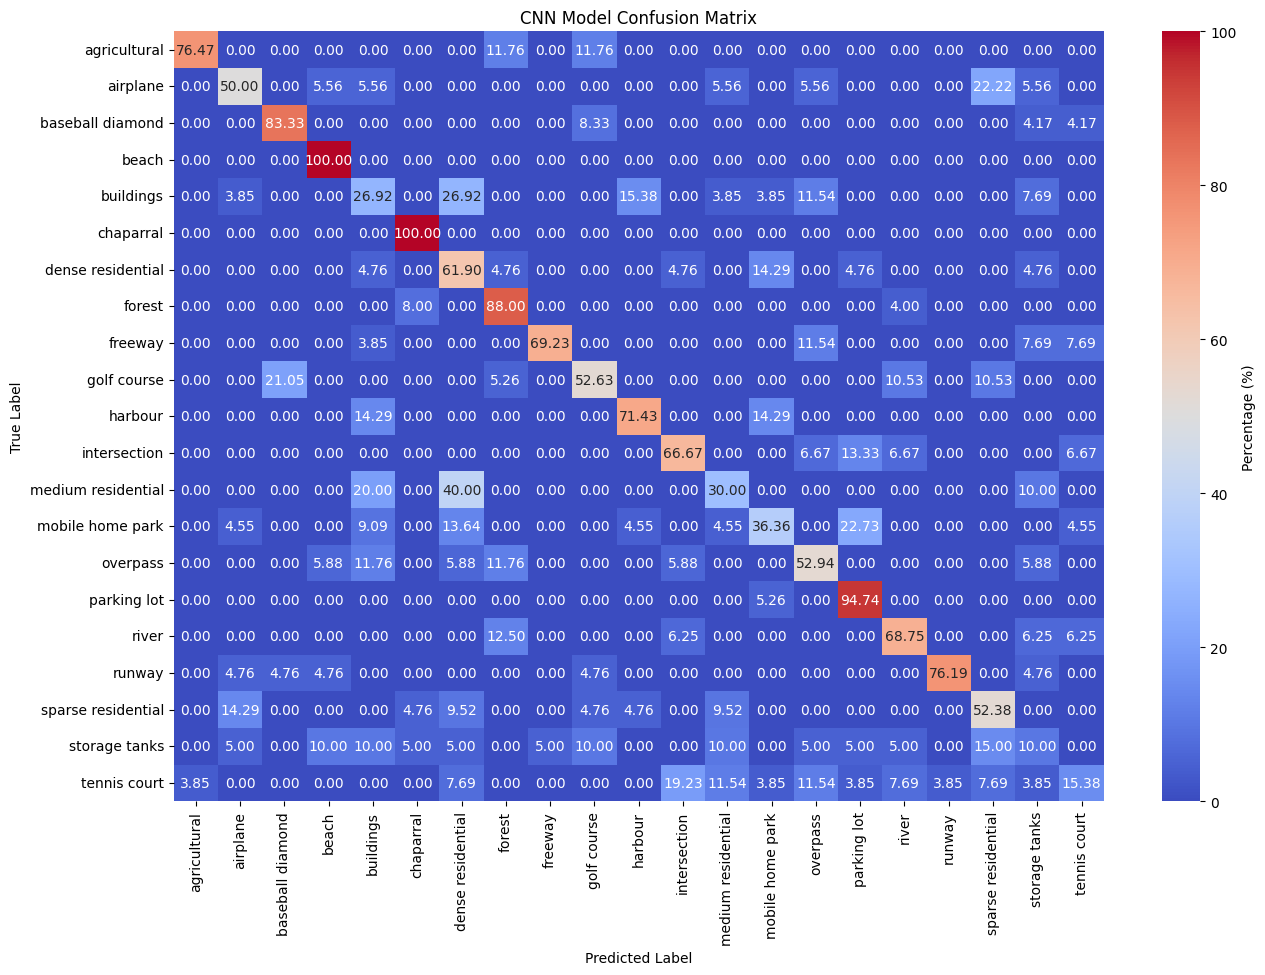

In [36]:
predicted_labels_matrix = model_cnn.predict(normalized_cnn_test_data)
predicted_labels_cnn = np.argmax(predicted_labels_matrix, axis=1)

confusion_matrix_helper(test_cnn_labels, 
                        predicted_labels_cnn, 
                        'CNN Model Confusion Matrix', 
                        figure_size=(15, 10),
                        color_map='coolwarm'
                        )

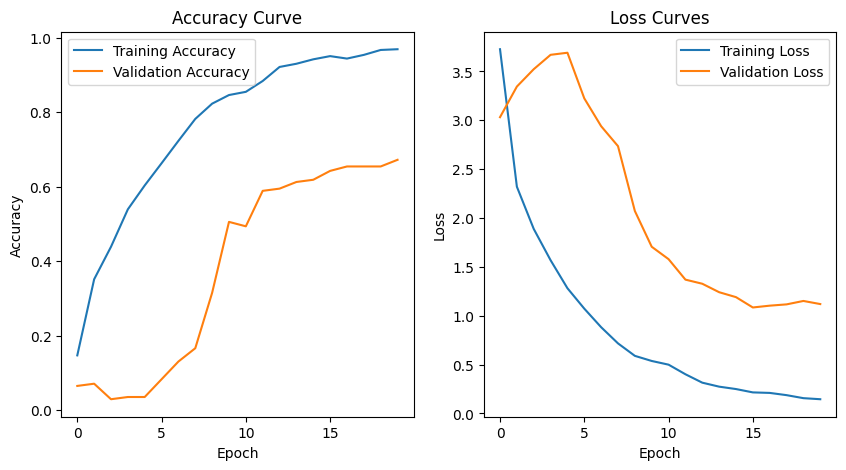

In [37]:
plt.figure(figsize=[10,5])

#Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_cnn.history['sparse_categorical_accuracy'])
plt.plot(history_cnn.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curve')

#Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')

plt.show()

## <a id='toc7_2_'></a>[Model 3B - CNN with data agumentation](#toc0_)

### <a id='toc7_2_2_'></a>[Split agumented data](#toc0_)

In [38]:
split_list_cnn_augmented = train_test_split(augmented_images,
                              augmented_label_list,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_cnn_data_augmented = split_list_cnn_augmented[0]
train_cnn_labels_augmented = split_list_cnn_augmented[2]

test_cnn_data_augmented = split_list_cnn_augmented[1]
test_cnn_labels_augmented = split_list_cnn_augmented[3]

### <a id='toc7_2_4_'></a>[Understanding Split Data](#toc0_)

In [39]:
unique_train_cnn_labels = set(np.unique(train_cnn_labels_augmented))

print("Train Data diversification")
for i in unique_train_cnn_labels:
    print(f"Label {i} : {list(train_cnn_labels_augmented).count(i)}")

Train Data diversification
Label 0 : 1884
Label 1 : 1889
Label 2 : 1899
Label 3 : 1911
Label 4 : 1896
Label 5 : 1902
Label 6 : 1874
Label 7 : 1889
Label 8 : 1891
Label 9 : 1909
Label 10 : 1870
Label 11 : 1897
Label 12 : 1874
Label 13 : 1884
Label 14 : 1891
Label 15 : 1872
Label 16 : 1867
Label 17 : 1883
Label 18 : 1910
Label 19 : 1908
Label 20 : 1890


In [40]:
unique_test_cnn_labels = np.unique(test_cnn_labels_augmented)
print("Test Data diversification")
for i in unique_test_cnn_labels:
    print(f"Label {i} : {list(test_cnn_labels_augmented).count(i)}")

Test Data diversification
Label 0 : 216
Label 1 : 211
Label 2 : 201
Label 3 : 189
Label 4 : 204
Label 5 : 198
Label 6 : 226
Label 7 : 211
Label 8 : 209
Label 9 : 191
Label 10 : 230
Label 11 : 203
Label 12 : 226
Label 13 : 216
Label 14 : 209
Label 15 : 228
Label 16 : 233
Label 17 : 217
Label 18 : 190
Label 19 : 192
Label 20 : 210


### <a id='toc7_2_5_'></a>[CNN defination and training](#toc0_)

In [41]:
normalized_cnn_train_data_augmented = train_cnn_data_augmented/255
normalized_cnn_test_data_augmented = test_cnn_data_augmented/255

In [42]:
#Filter variables for cnn
filter_count = 32
multiplier=0

early_stopping = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True, verbose=1)


#Define the model with layers and hyperparams as per requiremnets
model_cnn_augmented = tf.keras.Sequential(layers=[
    tf.keras.layers.Conv2D(filter_count, kernel_size=(3,3), activation=tf.nn.leaky_relu),    
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu, use_bias=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+2)), kernel_size=(3,3), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(filter_count*(2**(multiplier+4)), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(len(np.unique(land_cover_labels )), activation = tf.nn.softmax)])

#Add the optimizer, loss, metrics and finalize the configuration
model_cnn_augmented.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_cnn_augmeneted = model_cnn_augmented.fit(normalized_cnn_train_data_augmented,
                                train_cnn_labels_augmented,
                                epochs = 8,
                                validation_split = 0.1,
                                verbose = 1,
                                callbacks=[early_stopping]
                                )

Epoch 1/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 67s 55ms/step - loss: 2.3348 - sparse_categorical_accuracy: 0.3713 - val_loss: 0.8081 - val_sparse_categorical_accuracy: 0.7448
Epoch 2/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 175s 156ms/step - loss: 0.8491 - sparse_categorical_accuracy: 0.7263 - val_loss: 0.4948 - val_sparse_categorical_accuracy: 0.8410
Epoch 3/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 128s 114ms/step - loss: 0.5125 - sparse_categorical_accuracy: 0.8293 - val_loss: 0.3174 - val_sparse_categorical_accuracy: 0.9033
Epoch 4/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - loss: 0.3524 - sparse_categorical_accuracy: 0.8821 - val_loss: 0.2905 - val_sparse_categorical_accuracy: 0.9093
Epoch 5/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 56s 50ms/step - loss: 0.2542 - sparse_categorical_accuracy: 0.9143 - val_loss: 0.2137 - val_sparse_categorical_accuracy: 0.9297
Epoch 6/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 58s 52ms/step - loss: 0.1950 - sparse_categorical_accuracy: 0.9328 - val_loss: 0.1853 - val_sparse_categorical

In [43]:
model_cnn_augmented.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 59, 59, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 59, 59, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 21)             │        10,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,340,865 (20.37 MB)

 Trainable params: 1,780,181 (6.79 MB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 3,560,364 (13.58 MB)

In [44]:
#Use the testing data to check the accuraccy and if the model needs any tuning
results_cnn_augmented = model_cnn_augmented.evaluate(normalized_cnn_test_data_augmented, test_cnn_labels_augmented)

print(f'Test set loss: {results_cnn_augmented[0]:0.2f}, test set accuracy: {results_cnn_augmented[1]*100:0.2f}%')

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1687 - sparse_categorical_accuracy: 0.9450
Test set loss: 0.19, test set accuracy: 93.72%


### <a id='toc7_2_6_'></a>[Confusion matrix and accuracy curves](#toc0_)

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


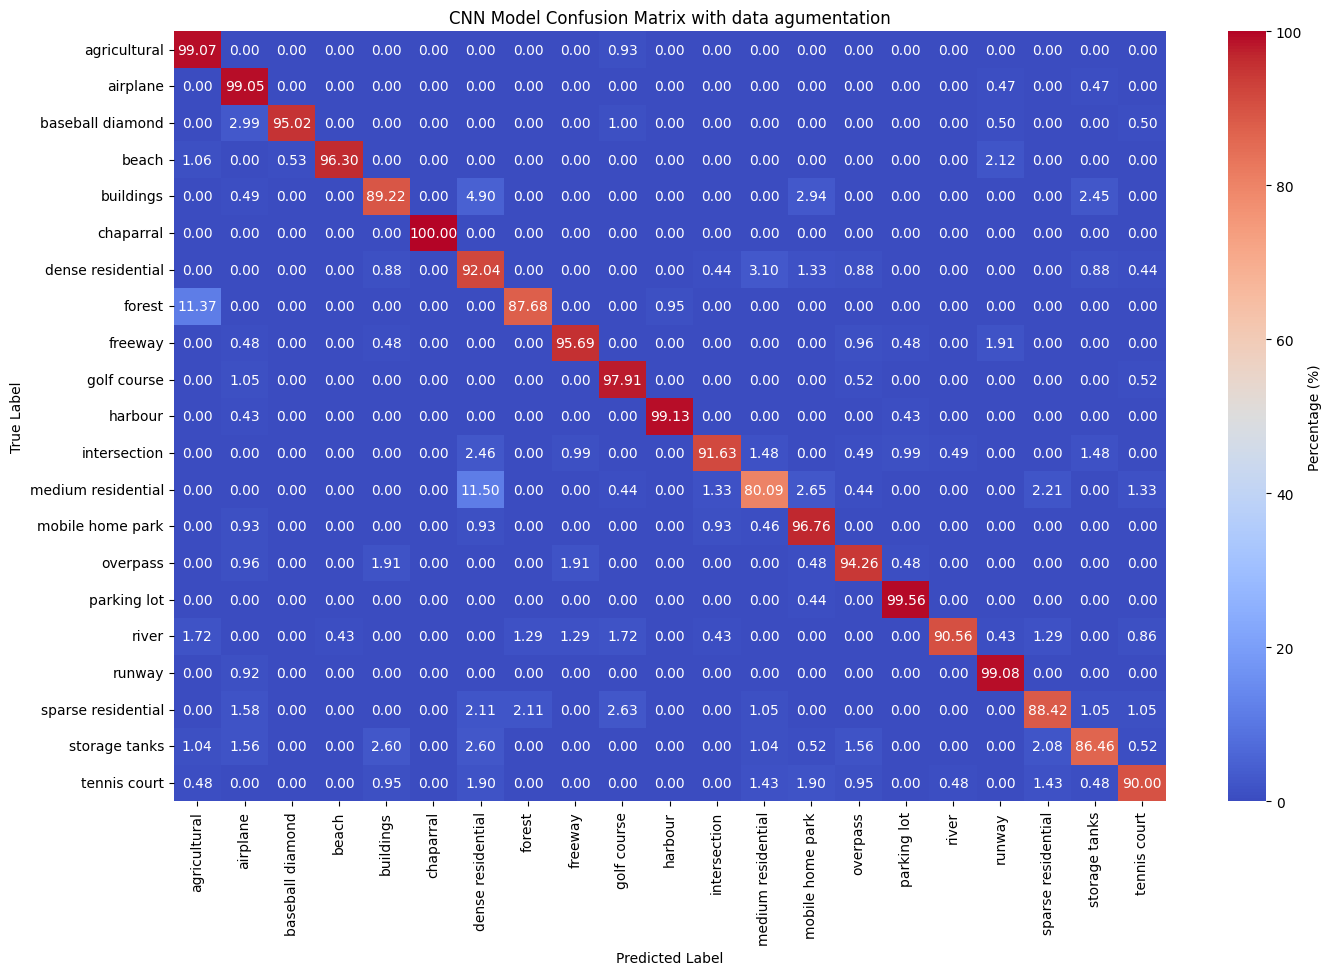

In [45]:
# Generate predictions and confusion matrix
predicted_labels_matrix = model_cnn_augmented.predict(normalized_cnn_test_data_augmented)
predicted_labels_cnn = np.argmax(predicted_labels_matrix, axis=1)

confusion_matrix_helper(test_cnn_labels_augmented, 
                        predicted_labels_cnn, 
                        'CNN Model Confusion Matrix with data agumentation', 
                        figure_size=(16, 10),
                        color_map='coolwarm'
                        )


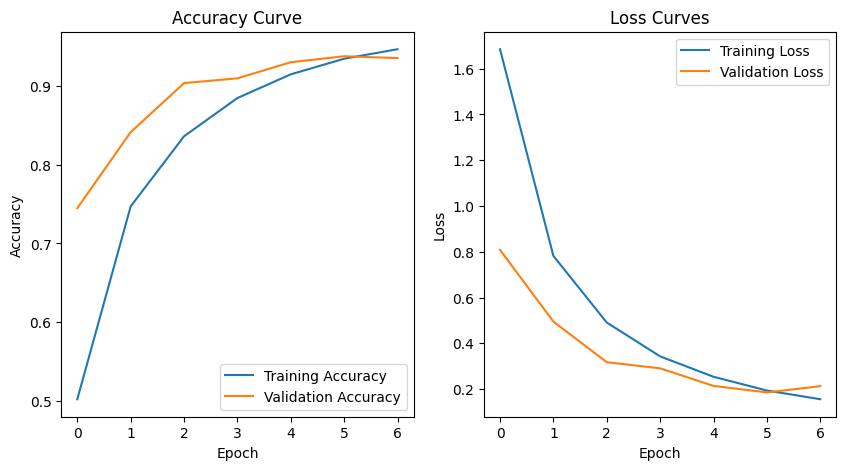

In [46]:
plt.figure(figsize=[10,5])

#Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_cnn_augmeneted.history['sparse_categorical_accuracy'])
plt.plot(history_cnn_augmeneted.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curve')

#Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_cnn_augmeneted.history['loss'])
plt.plot(history_cnn_augmeneted.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')

plt.show()

## <a id='toc7_3_'></a>[Save the data and model](#toc0_)

In [130]:
# Save the data and labels as .npy files
np.save('agumented_data.npy', augmented_images)  # Save training data
np.save('agumented_label_list.npy', augmented_label_list)  # Save training labels


In [190]:
model_cnn_augmented.save('model_cnn_terrain_validation946_test942.keras') 

In [9]:
# augmented_images = np.load('./Datasets/agumented_data.npy')
# augmented_label_list = np.load('./Datasets/agumented_label_list.npy')